# Netflix SQL Data Analysis Project

## Tools Used
- Python
- Pandas
- SQLite
- Matplotlib

## Project Objectives
- Analyze Netflix Movies and TV Shows dataset
- Perform SQL queries on real-world data
- Generate business insights through visualizations

## Key Insights
- TV-MA is the most common content rating.
- Movies significantly outnumber TV Shows.
- Content production increased rapidly after 2015.
- A few countries contribute the majority of Netflix content.

In [1]:
import pandas as pd
import sqlite3

df = pd.read_csv("netflix_titles.csv")

print("Shape:", df.shape)
print(df.columns)
df.head()

Shape: (8807, 12)
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
# Missing values check

df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [3]:
import sqlite3

conn = sqlite3.connect("netflix.db")

df.to_sql("netflix", conn, if_exists="replace", index=False)

print("Database created successfully!")

Database created successfully!


In [4]:
query = """
SELECT type, COUNT(*) AS total_content
FROM netflix
GROUP BY type
"""

result = pd.read_sql_query(query, conn)
result

,type,total_content
0,Movie,6131
1,TV Show,2676


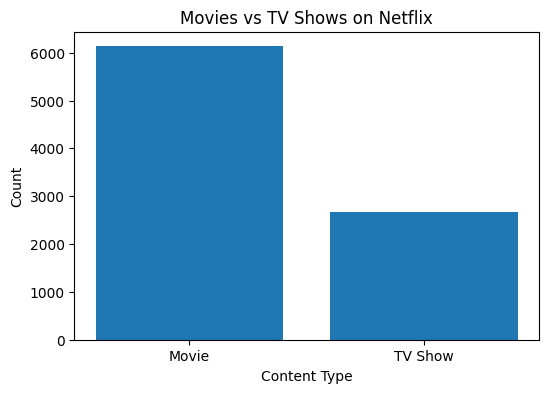

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(result["type"], result["total_content"])

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

In [6]:
query = """
SELECT country, COUNT(*) as total_content
FROM netflix
WHERE country IS NOT NULL
GROUP BY country
ORDER BY total_content DESC
LIMIT 10
"""

top_countries = pd.read_sql_query(query, conn)
top_countries

,country,total_content
0,United States,2818
1,India,972
2,United Kingdom,419
3,Japan,245
4,South Korea,199
5,Canada,181
6,Spain,145
7,France,124
8,Mexico,110
9,Egypt,106


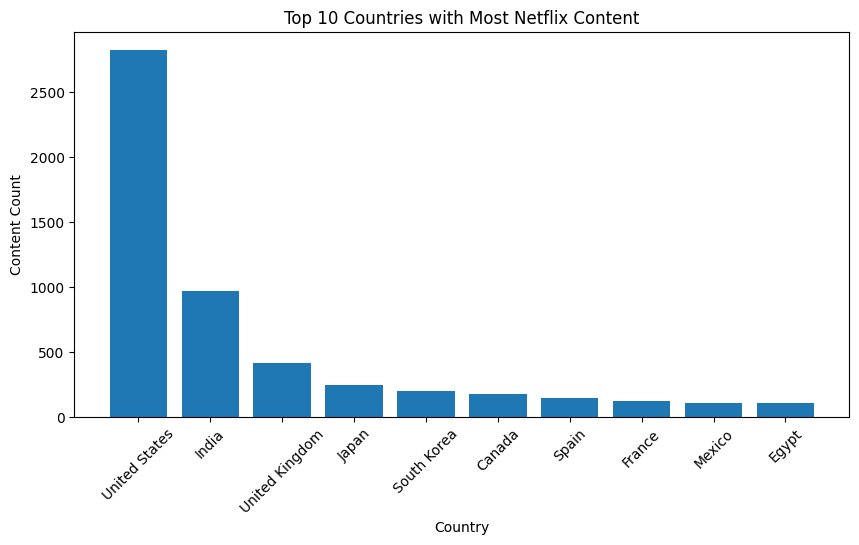

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(top_countries["country"],
        top_countries["total_content"])

plt.xticks(rotation=45)
plt.title("Top 10 Countries with Most Netflix Content")
plt.xlabel("Country")
plt.ylabel("Content Count")

plt.show()

In [8]:
query = """
SELECT listed_in, COUNT(*) as total
FROM netflix
GROUP BY listed_in
ORDER BY total DESC
LIMIT 10
"""

genres = pd.read_sql_query(query, conn)
genres

,listed_in,total
0,"Dramas, International Movies",362
1,Documentaries,359
2,Stand-Up Comedy,334
3,"Comedies, Dramas, International Movies",274
4,"Dramas, Independent Movies, International Movies",252
5,Kids' TV,220
6,Children & Family Movies,215
7,"Children & Family Movies, Comedies",201
8,"Documentaries, International Movies",186
9,"Dramas, International Movies, Romantic Movies",180


In [9]:
query = """
SELECT release_year,
COUNT(*) AS total_content
FROM netflix
GROUP BY release_year
ORDER BY release_year
"""

yearly = pd.read_sql_query(query, conn)

yearly.head()

,release_year,total_content
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4


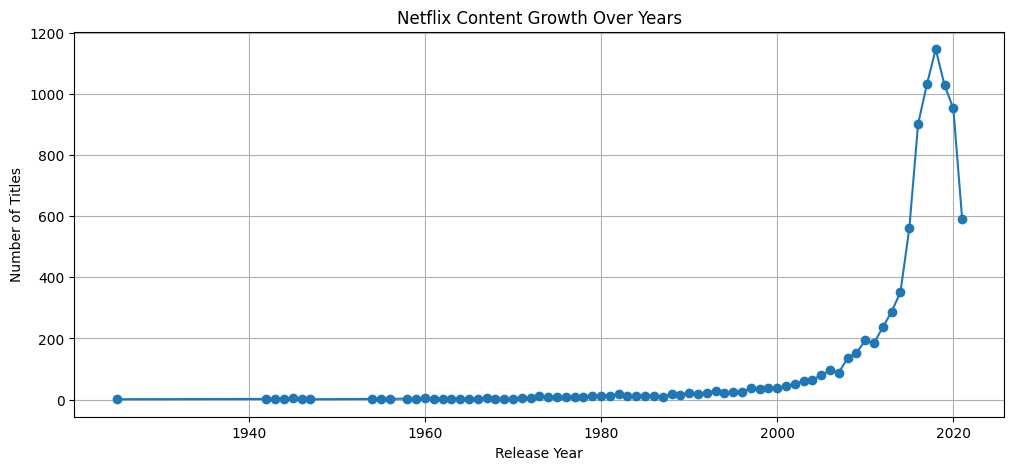

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(yearly["release_year"],
         yearly["total_content"],
         marker="o")

plt.title("Netflix Content Growth Over Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)

plt.show()

In [11]:
query = """
SELECT rating,
COUNT(*) AS total
FROM netflix
GROUP BY rating
ORDER BY total DESC
"""

ratings = pd.read_sql_query(query, conn)

ratings.head()

,rating,total
0,TV-MA,3207
1,TV-14,2160
2,TV-PG,863
3,R,799
4,PG-13,490


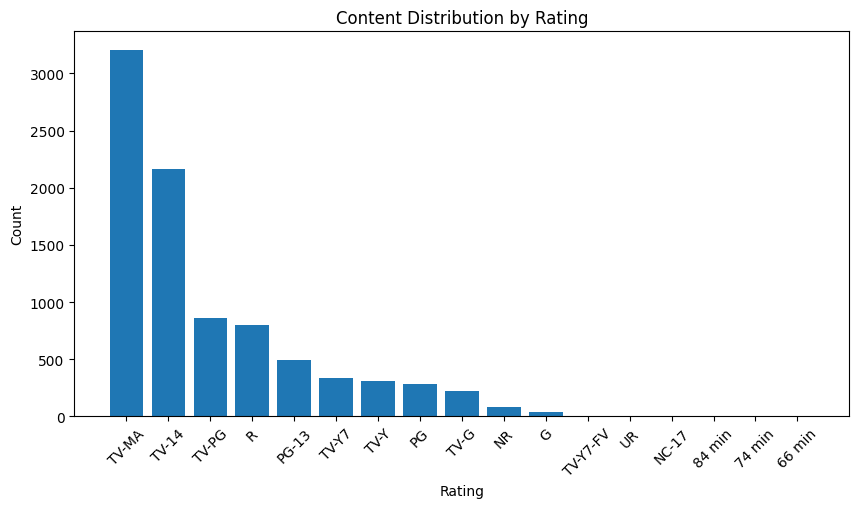

In [13]:
ratings = ratings.dropna()

plt.figure(figsize=(10,5))

plt.bar(ratings["rating"].astype(str),
        ratings["total"])

plt.title("Content Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()